# Check the methylation

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy import stats
import numpy as np


# to save the figures in adobe friendly fashion
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [8]:
cell_type = 'Oligo'
names = [x for x in os.listdir('./results/') if x.endswith('tss.csv') and cell_type in x]
names.sort()

In [9]:
names

['ASA_001B_cpg_Oligo_methylation_tss.csv',
 'ASA_002B_cpg_Oligo_methylation_tss.csv',
 'ASA_004B_cpg_Oligo_methylation_tss.csv',
 'ASA_005B_cpg_Oligo_methylation_tss.csv',
 'ASA_011B_cpg_Oligo_methylation_tss.csv',
 'ASA_015B_cpg_Oligo_methylation_tss.csv',
 'ASA_016B_cpg_Oligo_methylation_tss.csv',
 'ASA_018B_cpg_Oligo_methylation_tss.csv',
 'ASA_020B_cpg_Oligo_methylation_tss.csv',
 'ASA_021B_cpg_Oligo_methylation_tss.csv',
 'ASA_022B_cpg_Oligo_methylation_tss.csv',
 'ASA_024B_cpg_Oligo_methylation_tss.csv',
 'ASA_025B_cpg_Oligo_methylation_tss.csv',
 'ASA_029B_cpg_Oligo_methylation_tss.csv',
 'ASA_031B_cpg_Oligo_methylation_tss.csv',
 'ASA_032B_cpg_Oligo_methylation_tss.csv',
 'ASA_033B_cpg_Oligo_methylation_tss.csv',
 'ASA_034B_cpg_Oligo_methylation_tss.csv',
 'ASA_035B_cpg_Oligo_methylation_tss.csv',
 'ASA_040B_cpg_Oligo_methylation_tss.csv',
 'ASA_041B_cpg_Oligo_methylation_tss.csv',
 'ASA_042B_cpg_Oligo_methylation_tss.csv',
 'ASA_043B_cpg_Oligo_methylation_tss.csv',
 'ASA_046B_

In [10]:
results = []

for name in names:
    sample = pd.read_csv(f'results/{name}')
    name = name.replace('_methylation_tss.csv','')
    name = name.replace('_cpg','')
    name = name.replace(f'_{cell_type}','')
    sample = sample.set_index('expression')
    sample = sample.rename({'mean_methylation':name},axis='columns')
    sample = sample.drop(columns = 'sample')
    sample = sample.T
    results.append(sample)

In [11]:
combined_results = pd.concat(results, ignore_index=False)

In [12]:
combined_results

expression,high,low
ASA_001B,11.460414,51.983305
ASA_002B,18.122086,61.036442
ASA_004B,9.949099,49.454377
ASA_005B,9.517063,47.193654
ASA_011B,10.656911,49.360556
...,...,...
ASA_186B,9.214321,46.136017
ASA_187B,10.042258,46.802177
ASA_188B,9.289485,47.469225
ASA_189B,9.848702,46.507556


## Adding model metadata

In [ ]:
metadata = pd.read_csv('wgs_nanowgs_versions.csv') # supplementary table with WGS versioning and metadata, available as supplementary table with manuscipt
metada = metadata[metadata['basecaller'] == 'dorado']
metadata = metadata[~metadata['mod_model_basecalling'].isna()]
metadata = metadata.rename(columns={'Sample': 'sample_name', 'mod_model_basecalling':'mod_model','model_basecalling':'model'})
metadata = metadata[metadata['sample_name'].str.contains('B')] # make sure the is a B in the sample name to only look at Cingulate cortex data
metadata = metadata[metadata['mod_model'] != '6mA' ] # remove samples without 5mC calls
metadata = metadata[['sample_name', 'kit','method', 'model', 'mod_model', 'basecaller']]
metadata[:30] 

,sample_name,kit,method,model,mod_model,basecaller
0,ASA_001B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado
1,ASA_002B,SQK-LSK114,Fiber,dna_r10.4.1_e8.2_400bps_sup@v4.1.0-finetuned,"6mA,5mC",Dorado
2,ASA_004B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.2.0,5mCG_5hmCG,Dorado
3,ASA_005B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.1.0,5mCG_5hmCG,Dorado
4,ASA_011B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado
5,ASA_015B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado
6,ASA_016B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado
7,ASA_018B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado
8,ASA_020B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado
9,ASA_021B,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,Dorado


In [ ]:
metadata = metadata.set_index('sample_name')
metadata[:30]

In [18]:
joined = combined_results.join(metadata)

/tmp/ipykernel_462321/518465336.py:14: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(


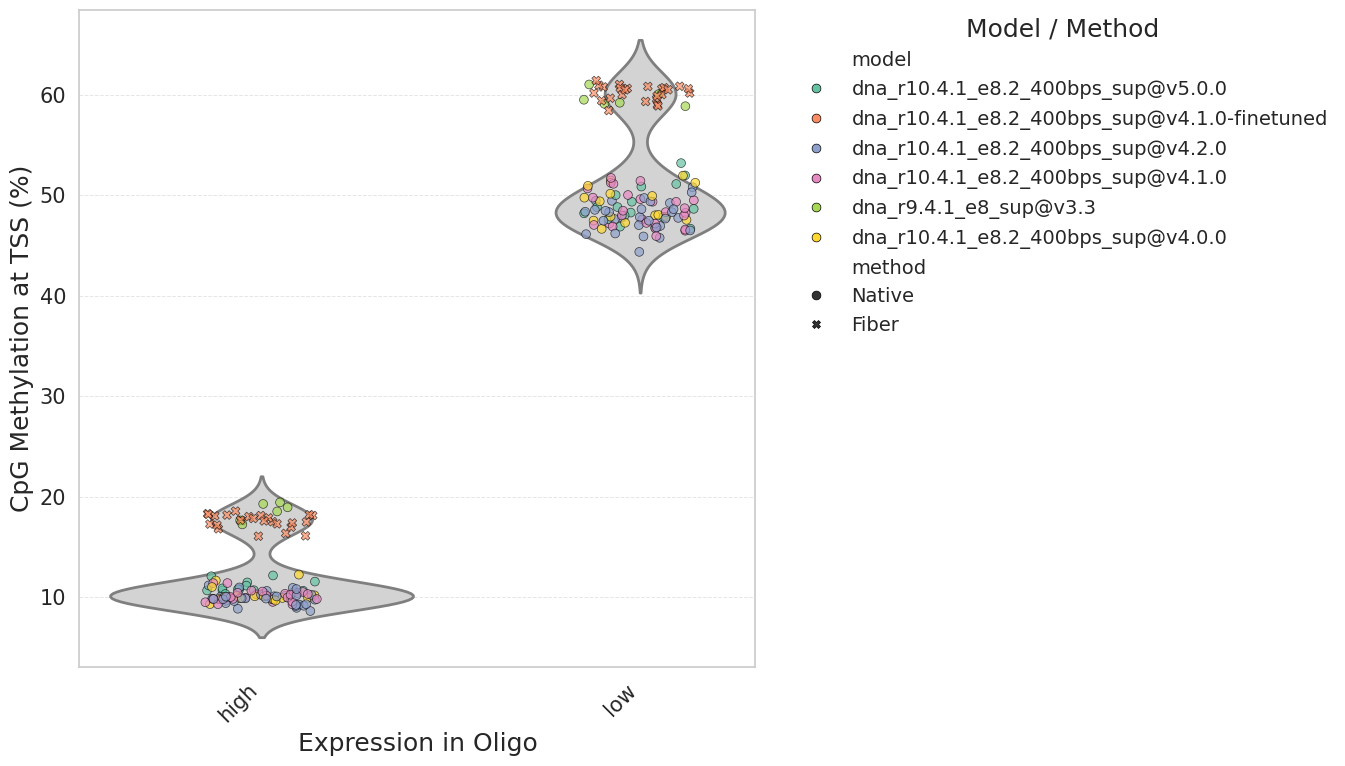

In [ ]:
df_reset = joined.reset_index()

tss_columns = ['high', 'low']

# Melt the dataframe to long format
df_melted = df_reset.melt(id_vars=['index', 'method','model'],  # Include 'method' in id_vars
                         value_vars=tss_columns,
                         var_name='expression', 
                         value_name='methylation')


palette = sns.color_palette("Set2")

plt.figure(figsize=(14, 8))


sns.violinplot(
    data=df_melted, x='expression', y='methylation',
    inner=None, linewidth=2, color='lightgray'
)


sns.scatterplot(
    data=df_melted, x='x_jitter', y='methylation',
    hue='model', style='method', s=40, alpha=0.7,
    palette=palette, edgecolor='black', linewidth=0.5
)

plt.xlabel(f'Expression in {cell_type}', fontsize=18)
plt.ylabel('CpG Methylation at TSS (%)', fontsize=18)
plt.xticks(ticks=[x_mapping[cat] for cat in x_categories], labels=x_categories, rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)

leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',  borderaxespad=0, fontsize=14, title='Model / Method', frameon=False)
for lh in leg.legendHandles:
    lh.set_alpha(1)
    
plt.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

# Save high-res figure
plt.savefig('figures/methylation_distribution_boxplot.pdf', bbox_inches='tight')
plt.show()

```
Package                              Version
------------------------------------ -----------------
adjustText                           1.0.4
aiohttp                              3.9.3
aiosignal                            1.3.1
anndata                              0.10.5.post1
annoy                                1.17.3
appdirs                              1.4.4
arboreto                             0.1.6
argparse-dataclass                   2.0.0
array_api_compat                     1.5.1
asttokens                            2.4.1
attr                                 0.3.2
attrs                                23.2.0
bbknn                                1.6.0
beautifulsoup4                       4.12.3
bidict                               0.23.1
bioservices                          1.11.2
blosc2                               2.5.1
bokeh                                3.4.0
boltons                              23.1.1
bs4                                  0.0.2
cattrs                               23.2.3
certifi                              2024.2.2
charset-normalizer                   3.3.2
click                                8.1.7
cloudpickle                          3.0.0
colorama                             0.4.6
colorlog                             6.8.2
comm                                 0.2.2
conda-inject                         1.3.1
ConfigArgParse                       1.7
connection_pool                      0.0.3
contourpy                            1.2.0
ctxcore                              0.2.0
cycler                               0.12.1
Cython                               0.29.37
cytoolz                              0.12.3
dask                                 2024.2.1
dataclasses-json                     0.6.4
datrie                               0.8.2
debugpy                              1.8.1
decorator                            5.1.1
dill                                 0.3.8
distributed                          2024.2.1
docutils                             0.20.1
dpath                                2.1.6
easydev                              0.13.1
et-xmlfile                           1.1.0
executing                            2.0.1
fastjsonschema                       2.19.1
fbpca                                1.0
filelock                             3.13.1
fonttools                            4.50.0
frozendict                           2.4.0
frozenlist                           1.4.1
fsspec                               2024.3.1
future                               1.0.0
gensim                               4.3.2
geosketch                            1.2
gevent                               24.2.1
gitdb                                4.0.11
GitPython                            3.1.42
globre                               0.1.5
greenlet                             3.0.3
grequests                            0.7.0
gseapy                               0.10.8
h5py                                 3.10.0
harmonypy                            0.0.9
humanfriendly                        10.0
idna                                 3.6
igraph                               0.11.4
imageio                              2.34.0
immutables                           0.20
importlib-metadata                   7.0.1
importlib_resources                  6.1.2
interlap                             0.2.7
intervaltree                         3.1.0
ipykernel                            6.29.3
ipython                              8.22.2
jedi                                 0.19.1
Jinja2                               3.1.3
joblib                               1.3.2
jsonpickle                           3.0.3
jsonschema                           4.21.1
jsonschema-specifications            2023.12.1
jupyter_client                       8.6.1
jupyter_core                         5.7.2
kaleido                              0.2.1
kiwisolver                           1.4.5
lazy_loader                          0.3
lda                                  3.0.0
leidenalg                            0.10.2
line-profiler                        4.1.2
llvmlite                             0.42.0
locket                               1.0.0
loompy                               3.0.7
loomxpy                              0.4.2
lxml                                 5.1.0
lz4                                  4.3.3
MACS2                                2.2.9.1
markdown-it-py                       3.0.0
MarkupSafe                           2.1.5
marshmallow                          3.21.1
matplotlib                           3.6.3
matplotlib-inline                    0.1.6
mdurl                                0.1.2
mizani                               0.9.3
msgpack                              1.0.8
mudata                               0.2.3
multidict                            6.0.5
multiprocessing_on_dill              3.5.0a4
mypy-extensions                      1.0.0
natsort                              8.4.0
nbformat                             5.10.3
ncls                                 0.0.68
ndindex                              1.8
nest-asyncio                         1.6.0
networkx                             3.2.1
numba                                0.59.0
numexpr                              2.9.0
numpy                                1.26.4
numpy-groupies                       0.10.2
openpyxl                             3.1.2
packaging                            24.0
pandas                               1.5.0
parso                                0.8.3
partd                                1.4.1
patsy                                0.5.6
pexpect                              4.9.0
pillow                               10.2.0
pip                                  24.0
plac                                 1.4.3
platformdirs                         4.2.0
plotly                               5.19.0
plotnine                             0.12.4
polars                               0.20.13
progressbar2                         4.4.2
prompt-toolkit                       3.0.43
protobuf                             5.26.0
psutil                               5.9.8
ptyprocess                           0.7.0
PuLP                                 2.8.0
pure-eval                            0.2.2
py-cpuinfo                           9.0.0
pyarrow                              15.0.0
pyarrow-hotfix                       0.6
pybedtools                           0.9.1
pybigtools                           0.1.2
pyBigWig                             0.3.22
pybiomart                            0.2.0
pycistarget                          1.0a2
pycisTopic                           2.0a0
pyfasta                              0.5.2
pygam                                0.9.0
Pygments                             2.17.2
pynndescent                          0.5.11
pyparsing                            3.1.2
pyranges                             0.0.111
pyrle                                0.0.39
pysam                                0.22.0
pyscenic                             0.12.1+7.g1cd059f
python-dateutil                      2.9.0.post0
python-utils                         3.8.2
pytz                                 2024.1
pyvis                                0.3.2
PyYAML                               6.0.1
pyzmq                                25.1.2
ray                                  2.9.3
referencing                          0.34.0
requests                             2.31.0
requests-cache                       1.2.0
reretry                              0.11.8
rich                                 13.7.1
rich-argparse                        1.4.0
rpds-py                              0.18.0
scanorama                            1.7.4
scanpy                               1.8.2
scatac_fragment_tools                0.1.0
scenicplus                           1.0a1
scikit-image                         0.22.0
scikit-learn                         1.3.2
scipy                                1.12.0
scrublet                             0.2.3
seaborn                              0.13.2
setuptools                           65.5.0
sinfo                                0.3.4
six                                  1.16.0
smart-open                           6.4.0
smmap                                5.0.1
snakemake                            8.5.5
snakemake-interface-common           1.17.1
snakemake-interface-executor-plugins 8.2.0
snakemake-interface-report-plugins   1.0.0
snakemake-interface-storage-plugins  3.1.1
sorted-nearest                       0.0.39
sortedcontainers                     2.4.0
soupsieve                            2.5
stack-data                           0.6.3
statistics                           1.0.3.5
statsmodels                          0.14.1
stdlib-list                          0.10.0
stopit                               1.1.2
suds-community                       1.1.2
tables                               3.9.2
tabulate                             0.9.0
tblib                                3.0.0
tenacity                             8.2.3
texttable                            1.7.0
threadpoolctl                        3.4.0
throttler                            1.2.2
tifffile                             2024.2.12
tmtoolkit                            0.12.0
toolz                                0.12.1
toposort                             1.10
tornado                              6.4
tqdm                                 4.66.2
traitlets                            5.14.2
tspex                                0.6.3
typing                               3.7.4.3
typing_extensions                    4.10.0
typing-inspect                       0.9.0
umap-learn                           0.5.5
url-normalize                        1.4.3
urllib3                              2.2.1
wcwidth                              0.2.13
wheel                                0.43.0
wrapt                                1.16.0
xlrd                                 2.0.1
xmltodict                            0.13.0
xyzservices                          2023.10.1
yarl                                 1.9.4
yte                                  1.5.4
zict                                 3.0.0
zipp                                 3.18.1
zope.event                           5.0
zope.interface                       6.2
```